# 05 · Naive Bayes: `src/naive_bayes/`

Tests for `GaussianNaiveBayes` and `MultinomialNaiveBayes` (`_naive_bayes.py`) and the evaluation helpers in `_eval_utils.py`.

| Data | Source | What it tests |
|---|---|---|
| Iris, Wine | scikit-learn, bundled | Gaussian NB parameters and probabilities match scikit-learn **exactly** |
| Gaussian blobs (2-D) | generated | quadratic decision boundaries, probability calibration |
| Digits as pixel counts (0–16) | scikit-learn, bundled | Multinomial NB matches scikit-learn **exactly** |
| 20 Newsgroups (4 topics) | **online** (`fetch_20newsgroups`) | text classification from word counts |

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets, naive_bayes as sknb, metrics as skm
from sklearn.model_selection import train_test_split

from _testkit import SEED, Checks, load_online, timed
from src.naive_bayes._naive_bayes import GaussianNaiveBayes, MultinomialNaiveBayes
from src.naive_bayes import _eval_utils as ev

checks = Checks("05 naive bayes")
rng = np.random.default_rng(SEED)

## 1. Gaussian NB learns the right parameters

The priors are the class frequencies. The means and variances are the per-class column statistics, computed with population variance (`ddof = 0`).

In [2]:
X_iris, y_iris = datasets.load_iris(return_X_y=True)
gnb = GaussianNaiveBayes()
result = gnb.fit(X_iris, y_iris)

checks.check("fit() returns None (documented quirk: no chaining)", result is None)
checks.close("priors_ = class frequencies", gnb.priors_, np.bincount(y_iris) / len(y_iris))
checks.close("mean_ = per-class means", gnb.mean_, np.array([X_iris[y_iris == c].mean(axis=0) for c in range(3)]))
checks.close("variance_ = per-class variances", gnb.variance_, np.array([X_iris[y_iris == c].var(axis=0) for c in range(3)]))

✅ fit() returns None (documented quirk: no chaining)
✅ priors_ = class frequencies  (max |Δ| = 0.00e+00)
✅ mean_ = per-class means  (max |Δ| = 0.00e+00)
✅ variance_ = per-class variances  (max |Δ| = 0.00e+00)


True

## 2. Gaussian NB matches scikit-learn exactly

scikit-learn adds `var_smoothing × max(feature variance)` to every variance, while we add a fixed `1e-9`. Setting `var_smoothing = 1e-9 / max variance` makes the two models mathematically identical, so their outputs should agree to machine precision.

In [3]:
for name, loader in [("Iris", datasets.load_iris), ("Wine", datasets.load_wine)]:
    X, y = loader(return_X_y=True)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)
    ours = GaussianNaiveBayes(); ours.fit(Xtr, ytr)
    ref = sknb.GaussianNB(var_smoothing=1e-9 / Xtr.var(axis=0).max()).fit(Xtr, ytr)

    checks.check(f"{name}: predictions identical to sklearn", np.array_equal(ours.predict(Xte), ref.predict(Xte)))
    checks.close(f"{name}: predict_proba == sklearn", ours.predict_proba(Xte), ref.predict_proba(Xte), atol=1e-8)
    checks.close(f"{name}: predict_log_proba == sklearn joint log-likelihood",
                 ours.predict_log_proba(Xte), ref.predict_joint_log_proba(Xte), rtol=1e-8, atol=1e-6)
    checks.at_least(f"{name}: test accuracy", ev.accuracy(yte, ours.predict(Xte)), 0.9)

✅ Iris: predictions identical to sklearn
✅ Iris: predict_proba == sklearn  (max |Δ| = 5.55e-16)
✅ Iris: predict_log_proba == sklearn joint log-likelihood  (max |Δ| = 1.14e-13)
✅ Iris: test accuracy  (0.9111 ≥ 0.9)
✅ Wine: predictions identical to sklearn
✅ Wine: predict_proba == sklearn  (max |Δ| = 2.89e-15)
✅ Wine: predict_log_proba == sklearn joint log-likelihood  (max |Δ| = 4.26e-14)
✅ Wine: test accuracy  (1.0000 ≥ 0.9)


### Probabilities and decision boundaries

Each class gets its own variance, so Gaussian NB draws **quadratic** boundaries (ellipses), not straight lines.

✅ probability rows sum to 1  (max |Δ| = 2.22e-16)
✅ argmax(predict_proba) == predict
✅ argmax(predict_log_proba) == predict
✅ blobs: training accuracy  (0.9422 ≥ 0.93)
✅ well-calibrated on Gaussian data (|mean confidence − accuracy|)  (0.0059 ≤ 0.05)


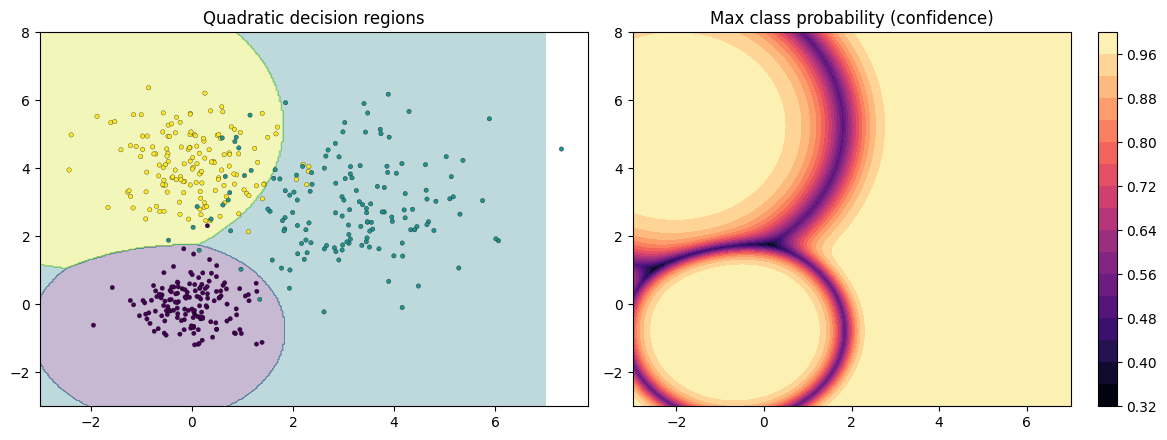

In [4]:
X_blob, y_blob = datasets.make_blobs(n_samples=450, centers=[[0, 0], [3, 3], [0, 4]], cluster_std=[0.6, 1.4, 0.9], random_state=SEED)
gb = GaussianNaiveBayes(); gb.fit(X_blob, y_blob)
P = gb.predict_proba(X_blob)
checks.close("probability rows sum to 1", P.sum(axis=1), np.ones(len(P)))
checks.check("argmax(predict_proba) == predict", np.array_equal(gb.classes_[P.argmax(axis=1)], gb.predict(X_blob)))
checks.check("argmax(predict_log_proba) == predict", np.array_equal(gb.classes_[gb.predict_log_proba(X_blob).argmax(axis=1)], gb.predict(X_blob)))
checks.at_least("blobs: training accuracy", ev.accuracy(y_blob, gb.predict(X_blob)), 0.93)

# Calibration: among samples predicted with ~p confidence, a fraction ~p should be right.
conf = P.max(axis=1); right = gb.predict(X_blob) == y_blob
checks.at_most("well-calibrated on Gaussian data (|mean confidence − accuracy|)", abs(conf.mean() - right.mean()), 0.05)

xx, yy = np.meshgrid(np.linspace(-3, 7, 300), np.linspace(-3, 8, 300))
grid_p = gb.predict_proba(np.c_[xx.ravel(), yy.ravel()])
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].contourf(xx, yy, grid_p.argmax(1).reshape(xx.shape), alpha=0.3, cmap="viridis")
ax[0].scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, s=10, cmap="viridis", edgecolor="k", linewidth=0.2)
ax[0].set_title("Quadratic decision regions")
im = ax[1].contourf(xx, yy, grid_p.max(1).reshape(xx.shape), levels=20, cmap="magma")
ax[1].set_title("Max class probability (confidence)"); plt.colorbar(im, ax=ax[1])
plt.tight_layout(); plt.show()

## 3. Multinomial NB matches scikit-learn exactly

Digits pixels are integer intensities from 0 to 16, which we treat as counts. `MultinomialNaiveBayes(alpha)` uses the same Laplace smoothing formula as scikit-learn's `MultinomialNB(alpha)`, so the two should be identical.

In [5]:
X_dig, y_dig = datasets.load_digits(return_X_y=True)
Xtr, Xte, ytr, yte = train_test_split(X_dig, y_dig, test_size=0.3, random_state=SEED, stratify=y_dig)

for alpha in [1.0, 0.1]:
    ours = MultinomialNaiveBayes(alpha=alpha); ours.fit(Xtr, ytr)
    ref = sknb.MultinomialNB(alpha=alpha).fit(Xtr, ytr)
    checks.close(f"α={alpha}: class_log_prior_ == sklearn", ours.class_log_prior_, ref.class_log_prior_)
    checks.close(f"α={alpha}: feature_log_prob_ == sklearn", ours.feature_log_prob_, ref.feature_log_prob_)
    checks.check(f"α={alpha}: predictions identical to sklearn", np.array_equal(ours.predict(Xte), ref.predict(Xte)))
    checks.close(f"α={alpha}: predict_proba == sklearn", ours.predict_proba(Xte), ref.predict_proba(Xte), atol=1e-8)

mnb = MultinomialNaiveBayes(alpha=1.0); mnb.fit(Xtr, ytr)
checks.at_least("Digits: test accuracy", ev.accuracy(yte, mnb.predict(Xte)), 0.85)
checks.check("fit() returns None (documented quirk)", MultinomialNaiveBayes().fit(Xtr, ytr) is None)

✅ α=1.0: class_log_prior_ == sklearn  (max |Δ| = 0.00e+00)
✅ α=1.0: feature_log_prob_ == sklearn  (max |Δ| = 1.78e-15)
✅ α=1.0: predictions identical to sklearn
✅ α=1.0: predict_proba == sklearn  (max |Δ| = 1.12e-13)
✅ α=0.1: class_log_prior_ == sklearn  (max |Δ| = 0.00e+00)
✅ α=0.1: feature_log_prob_ == sklearn  (max |Δ| = 1.78e-15)
✅ α=0.1: predictions identical to sklearn
✅ α=0.1: predict_proba == sklearn  (max |Δ| = 1.13e-13)
✅ Digits: test accuracy  (0.8759 ≥ 0.85)
✅ fit() returns None (documented quirk)


True

### What did the model learn?

Each class's `feature_log_prob_` is a probability map over the 64 pixels, so plotting it shows an "average digit" for each class.

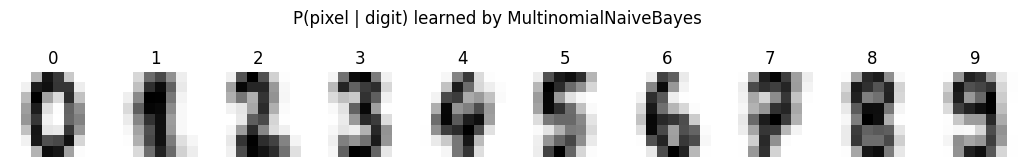

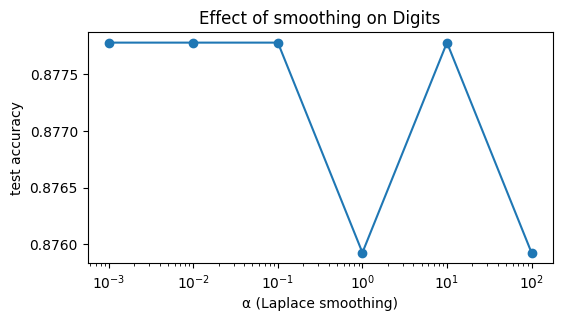

In [6]:
fig, axes = plt.subplots(1, 10, figsize=(13, 1.8))
for d, ax in enumerate(axes):
    ax.imshow(np.exp(mnb.feature_log_prob_[d]).reshape(8, 8), cmap="gray_r"); ax.set_title(str(d)); ax.axis("off")
plt.suptitle("P(pixel | digit) learned by MultinomialNaiveBayes", y=1.08); plt.show()

alphas = [1e-3, 1e-2, 0.1, 1, 10, 100]
accs = []
for a in alphas:
    m = MultinomialNaiveBayes(alpha=a); m.fit(Xtr, ytr); accs.append(ev.accuracy(yte, m.predict(Xte)))
plt.figure(figsize=(6, 3)); plt.semilogx(alphas, accs, "o-"); plt.xlabel("α (Laplace smoothing)"); plt.ylabel("test accuracy")
plt.title("Effect of smoothing on Digits"); plt.show()

## 4. Evaluation utilities match scikit-learn

In [7]:
y_true = rng.integers(0, 3, 300)
y_pred = np.where(rng.random(300) < 0.7, y_true, rng.integers(0, 3, 300))   # ~70 % correct, 3 classes
yb_true, yb_pred = rng.integers(0, 2, 200), rng.integers(0, 2, 200)

checks.check("confusion_matrix == sklearn", np.array_equal(ev.confusion_matrix(y_true, y_pred), skm.confusion_matrix(y_true, y_pred)))
checks.close("accuracy == sklearn", ev.accuracy(y_true, y_pred), skm.accuracy_score(y_true, y_pred))
for avg in ["macro", "weighted"]:
    checks.close(f"precision({avg}) == sklearn", ev.precision(y_true, y_pred, average=avg), skm.precision_score(y_true, y_pred, average=avg))
    checks.close(f"recall({avg}) == sklearn", ev.recall(y_true, y_pred, average=avg), skm.recall_score(y_true, y_pred, average=avg))
    checks.close(f"f1_score({avg}) == sklearn", ev.f1_score(y_true, y_pred, average=avg), skm.f1_score(y_true, y_pred, average=avg))
checks.close("binary precision == sklearn", ev.precision(yb_true, yb_pred), skm.precision_score(yb_true, yb_pred))
checks.close("binary recall == sklearn", ev.recall(yb_true, yb_pred), skm.recall_score(yb_true, yb_pred))
checks.close("binary f1 == sklearn", ev.f1_score(yb_true, yb_pred), skm.f1_score(yb_true, yb_pred))

report = ev.evaluate_classification_model(yb_true, yb_pred, target_names=["neg", "pos"])
checks.check("evaluate_classification_model returns the metrics dict",
             set(report) == {"accuracy", "precision", "recall", "f1", "confusion_matrix"})

def _multiclass_report_is_averaged():
    # On 3-class data the summary 'precision' should be an average over classes,
    # not silently the precision of class 0 (average='binary' falls back to class 0).
    import contextlib, io
    with contextlib.redirect_stdout(io.StringIO()):
        r = ev.evaluate_classification_model(y_true, y_pred)
    return np.isclose(r["precision"], skm.precision_score(y_true, y_pred, average="macro"))

checks.known_bug("evaluate_classification_model averages multi-class metrics", _multiclass_report_is_averaged,
                 "with >2 classes it reports class 0's precision/recall/F1 instead of an average")

✅ confusion_matrix == sklearn
✅ accuracy == sklearn  (max |Δ| = 0.00e+00)
✅ precision(macro) == sklearn  (max |Δ| = 0.00e+00)
✅ recall(macro) == sklearn  (max |Δ| = 0.00e+00)
✅ f1_score(macro) == sklearn  (max |Δ| = 0.00e+00)
✅ precision(weighted) == sklearn  (max |Δ| = 0.00e+00)
✅ recall(weighted) == sklearn  (max |Δ| = 0.00e+00)
✅ f1_score(weighted) == sklearn  (max |Δ| = 1.11e-16)
✅ binary precision == sklearn  (max |Δ| = 0.00e+00)
✅ binary recall == sklearn  (max |Δ| = 0.00e+00)
✅ binary f1 == sklearn  (max |Δ| = 0.00e+00)
Confusion Matrix:
                     neg          pos
         neg            49           42
         pos            64           45

Accuracy:  0.4700
Precision: 0.5172
Recall:    0.4128
F1-Score:  0.4592
✅ evaluate_classification_model returns the metrics dict
🐞 evaluate_classification_model averages multi-class metrics  (with >2 classes it reports class 0's precision/recall/F1 instead of an average)


False

## 5. Real data (online): 20 Newsgroups text classification

We take four newsgroups (space, cars, graphics, Middle-East politics), strip headers, footers and quotes, and turn each post into word counts with `CountVectorizer`, which is preprocessing only. Multinomial NB is the classic baseline for this task.

🌐 20 Newsgroups: downloaded / loaded from cache


2335 training posts, vocabulary of 14377 words
⏱️ MultinomialNaiveBayes fit + predict (sparse input): 0.00s
test accuracy  ours: 0.8971 | sklearn: 0.8971
✅ 20 Newsgroups: test accuracy  (0.8971 ≥ 0.85)
✅ 20 Newsgroups: predictions identical to sklearn
Most probable words per topic:


,comp.graphics,rec.autos,sci.space,talk.politics.mideast
0,image,car,space,people
1,graphics,cars,nasa,armenian
2,edu,like,launch,armenians
3,jpeg,just,like,said
4,file,don,earth,israel
5,use,good,data,turkish
6,data,new,orbit,jews
7,files,engine,time,know


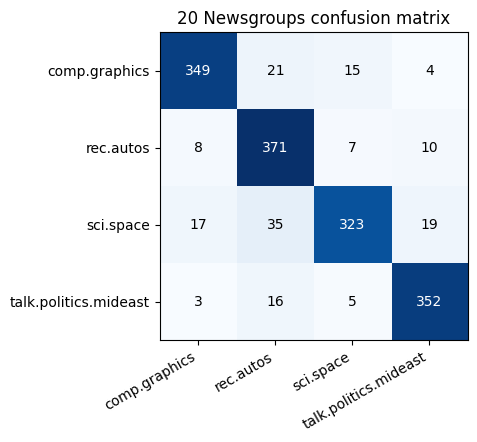

In [8]:
CATS = ["sci.space", "rec.autos", "comp.graphics", "talk.politics.mideast"]

def _newsgroups():
    from sklearn.datasets import fetch_20newsgroups
    kw = dict(categories=CATS, remove=("headers", "footers", "quotes"))
    return fetch_20newsgroups(subset="train", **kw), fetch_20newsgroups(subset="test", **kw)

news, online = load_online("20 Newsgroups", _newsgroups)
if online:
    from sklearn.feature_extraction.text import CountVectorizer
    train, test = news
    vec = CountVectorizer(stop_words="english", min_df=2)
    Xtr_t, Xte_t = vec.fit_transform(train.data), vec.transform(test.data)
    print(f"{Xtr_t.shape[0]} training posts, vocabulary of {Xtr_t.shape[1]} words")

    with timed("MultinomialNaiveBayes fit + predict (sparse input)"):
        txt = MultinomialNaiveBayes(alpha=0.1); txt.fit(Xtr_t, train.target); pred = txt.predict(Xte_t)
    ref = sknb.MultinomialNB(alpha=0.1).fit(Xtr_t, train.target)

    acc_t = ev.accuracy(test.target, pred)
    print(f"test accuracy  ours: {acc_t:.4f} | sklearn: {ref.score(Xte_t, test.target):.4f}")
    checks.at_least("20 Newsgroups: test accuracy", acc_t, 0.85)
    checks.check("20 Newsgroups: predictions identical to sklearn", np.array_equal(pred, ref.predict(Xte_t)))

    vocab = np.array(vec.get_feature_names_out())
    top = pd.DataFrame({c: vocab[np.argsort(txt.feature_log_prob_[i])[::-1][:8]] for i, c in enumerate(train.target_names)})
    print("Most probable words per topic:"); display(top)

    cm = ev.confusion_matrix(test.target, pred)
    plt.figure(figsize=(5, 4)); plt.imshow(cm, cmap="Blues")
    plt.xticks(range(4), train.target_names, rotation=30, ha="right"); plt.yticks(range(4), train.target_names)
    for i in range(4):
        for j in range(4):
            plt.text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > cm.max() / 2 else "black")
    plt.title("20 Newsgroups confusion matrix"); plt.show()
else:
    checks.skip("20 Newsgroups checks", "dataset unavailable offline")

## 6. API contract and input validation

In [9]:
checks.raises("Gaussian: predict before fit raises RuntimeError", RuntimeError, lambda: GaussianNaiveBayes().predict(X_iris))
checks.raises("Multinomial: predict before fit raises RuntimeError", RuntimeError, lambda: MultinomialNaiveBayes().predict(X_dig))
checks.raises("Gaussian: X / y length mismatch raises", ValueError, lambda: GaussianNaiveBayes().fit(X_iris, y_iris[:-1]))
g = GaussianNaiveBayes(); g.fit(X_iris, y_iris)
checks.raises("Gaussian: wrong number of features at predict raises", ValueError, lambda: g.predict(X_iris[:, :2]))
y_str = np.array(["a", "b", "c"])[y_iris]
gs = GaussianNaiveBayes(); gs.fit(X_iris, y_str)
checks.check("string labels are supported", set(gs.predict(X_iris)) <= {"a", "b", "c"})

✅ Gaussian: predict before fit raises RuntimeError  (RuntimeError: Model not fitted. Call fit() before predict().)
✅ Multinomial: predict before fit raises RuntimeError  (RuntimeError: Model not fitted. Call fit() before predict().)
✅ Gaussian: X / y length mismatch raises  (ValueError: X and y length mismatch: X has 150 samples, y has 149 samples)
✅ Gaussian: wrong number of features at predict raises  (ValueError: X has 2 features but model was fitted with 4 features)
✅ string labels are supported


True

## Summary

In [10]:
checks.summary()

05 naive bayes: 46 passed, 0 failed, 0 skipped, 1 known bug(s) (47 checks)

Known library bugs (not counted as failures):
  🐞 evaluate_classification_model averages multi-class metrics: with >2 classes it reports class 0's precision/recall/F1 instead of an average


,check,status,detail
0,fit() returns None (documented quirk: no chain...,pass,
1,priors_ = class frequencies,pass,max |Δ| = 0.00e+00
2,mean_ = per-class means,pass,max |Δ| = 0.00e+00
3,variance_ = per-class variances,pass,max |Δ| = 0.00e+00
4,Iris: predictions identical to sklearn,pass,
5,Iris: predict_proba == sklearn,pass,max |Δ| = 5.55e-16
6,Iris: predict_log_proba == sklearn joint log-l...,pass,max |Δ| = 1.14e-13
7,Iris: test accuracy,pass,0.9111 ≥ 0.9
8,Wine: predictions identical to sklearn,pass,
9,Wine: predict_proba == sklearn,pass,max |Δ| = 2.89e-15
